In [13]:
print("I am sb")

I am sb


In [14]:
# !pip install -q "monai[nibabel, tqdm]" joblib scikit-image

In [ ]:
import os
import sys

# Add project root to path for imports
PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname(os.getcwd())))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Configuration
testId = 148
trainMore = True

# Model selection: 'resunet', 'attenunet', 'unet3d', 'unet2d', 'vnet'
MODEL_NAME = 'resunet'  # Change this to switch models

# Paths - using relative paths from project root
PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname(os.getcwd())))
BASE_DIR = os.path.join(PROJECT_ROOT, 'data')
PROCESSED_DIR = os.path.join(BASE_DIR, 'processed')

# Import dataset utilities for proper preprocessing
from config.config import paths, train_cfg
from src.dataset import create_datasets, _gather_brats_cases, get_transforms_3d

# Determine spatial dimensions based on model
SPATIAL_DIMS = 2 if MODEL_NAME == 'unet2d' else 3

# Model path - uses standard naming: best_{model_name}.pth
MODELS_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'models')
BEST_MODEL_PATH = os.path.join(MODELS_DIR, f'best_{MODEL_NAME}.pth')

# Verify model file exists
if not os.path.exists(BEST_MODEL_PATH):
    print(f"⚠️ Warning: Model file not found: {BEST_MODEL_PATH}")
    print(f"Available models in {MODELS_DIR}:")
    if os.path.exists(MODELS_DIR):
        available = [f for f in os.listdir(MODELS_DIR) if f.startswith('best_') and f.endswith('.pth')]
        for model_file in available:
            print(f"  - {model_file}")
        if available:
            print(f"\n💡 Suggestion: Set MODEL_NAME to one of: {[f.replace('best_', '').replace('.pth', '') for f in available]}")
    else:
        print(f"   Models directory does not exist: {MODELS_DIR}")
else:
    print(f"✅ Model path: {BEST_MODEL_PATH}")
    print(f"✅ Using raw training data from: {paths.data_train}")
    print(f"✅ Spatial dimensions: {SPATIAL_DIMS}D")

✅ Model path: c:\Users\ravin\OneDrive\Desktop\Coursework\DSAI-lab\Project\outputs\models\best_resunet.pth


Using device: cuda
✅ Model loaded successfully from: c:\Users\ravin\OneDrive\Desktop\Coursework\DSAI-lab\Project\outputs\models\best_resunet.pth
   Best Dice Score: 0.7587440609931946
Model type: resunet

=== Running Full Analysis for Patient: BraTS-GLI-01493-000 ===

--- Volumetric and Accuracy Analysis ---
-------------------------------------------------------------------------------------
Tumor Component           | Ground Truth Volume  | Predicted Volume     | Dice Score (Accuracy)
-------------------------------------------------------------------------------------
Whole Tumor (WT)          | 15487.00             | 8876.00              | 0.4429              
Tumor Core (TC)           | 32228.00             | 52493.00             | 0.6963              
Enhancing Tumor (ET)      | 7706.00              | 2799.00              | 0.0143              
-------------------------------------------------------------------------------------


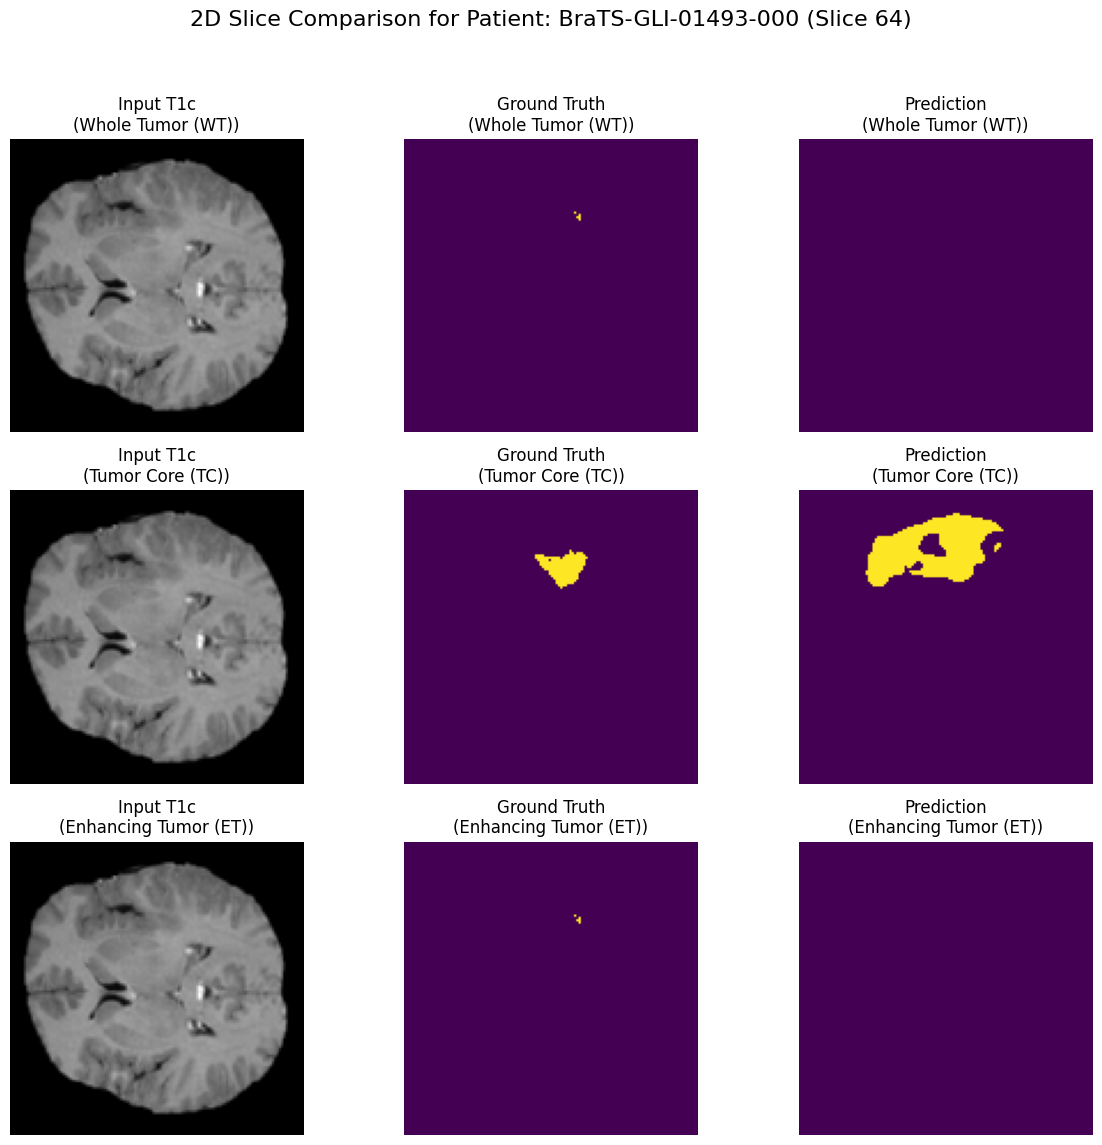

In [ ]:
#Visual Before
import numpy as np
import torch
import matplotlib.pyplot as plt
from monai.networks.nets import AttentionUnet, SegResNet, VNet, UNet
from monai.inferers import sliding_window_inference
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Spacingd,
    CropForegroundd,
    Resized,
    ScaleIntensityRanged,
    ConvertToMultiChannelBasedOnBratsClassesd,
    EnsureTyped
)
from skimage.measure import label, marching_cubes
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ==============================================================================
# Part 1: Configuration and Model Loading
# ==============================================================================

# --- Device Configuration ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# --- Model Definition (based on MODEL_NAME from cell above) ---
if MODEL_NAME == 'resunet':
    model = SegResNet(
        spatial_dims=3,
        in_channels=4,
        out_channels=3,
        init_filters=16,
        blocks_down=(1, 2, 2, 4),
        blocks_up=(1, 1, 1),
    ).to(device)
elif MODEL_NAME == 'attenunet':
    model = AttentionUnet(
        spatial_dims=3,
        in_channels=4,
        out_channels=3,
        channels=(16, 32, 64, 128),
        strides=(2, 2, 2, 2),
    ).to(device)
elif MODEL_NAME == 'unet3d':
    model = UNet(
        spatial_dims=3,
        in_channels=4,
        out_channels=3,
        channels=(16, 32, 64, 128),
        strides=(2, 2, 2, 2),
        num_res_units=2,
    ).to(device)
elif MODEL_NAME == 'unet2d':
    model = UNet(
        spatial_dims=2,
        in_channels=4,
        out_channels=3,
        channels=(32, 64, 128, 256),
        strides=(2, 2, 2, 2),
        num_res_units=2,
    ).to(device)
elif MODEL_NAME == 'vnet':
    model = VNet(
        spatial_dims=3,
        in_channels=4,
        out_channels=3,
    ).to(device)
else:
    raise ValueError(f"Unknown model name: {MODEL_NAME}")

# --- Load Pre-trained Weights ---
if not os.path.exists(BEST_MODEL_PATH):
    raise FileNotFoundError(
        f"Model checkpoint not found: {BEST_MODEL_PATH}\n"
        f"Please train a model first or check the MODEL_NAME variable."
    )

map_location = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
try:
    checkpoint = torch.load(BEST_MODEL_PATH, map_location=map_location)
    
    # Handle different checkpoint formats
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        # Fallback: assume the checkpoint is the state dict directly
        model.load_state_dict(checkpoint)
    
    print(f"✅ Model loaded successfully from: {BEST_MODEL_PATH}")
    if 'metrics' in checkpoint:
        best_dice = checkpoint.get('metrics', {}).get('best_dice', 'N/A')
        print(f"   Best Dice Score: {best_dice}")
except Exception as e:
    raise RuntimeError(f"Error loading model checkpoint: {e}")

model.eval()
print(f"Model type: {MODEL_NAME}")

# ==============================================================================
# Part 2: Preprocessing and Post-Processing Functions (Same as before)
# ==============================================================================

# --- Post-Processing Function ---
def remove_small_lesions(pred_mask_np, min_size_map):
    processed_mask = np.zeros_like(pred_mask_np)
    for c in range(pred_mask_np.shape[0]):
        channel_mask = pred_mask_np[c]
        if np.sum(channel_mask) > 0:
            labeled_mask = label(channel_mask)
            min_size = min_size_map.get(c, 50)
            for region_label in range(1, np.max(labeled_mask) + 1):
                if np.sum(labeled_mask == region_label) > min_size:
                    processed_mask[c][labeled_mask == region_label] = 1
    return processed_mask

# ==============================================================================
# Part 3: Volumetric and 3D Visualization Functions (NEW)
# ==============================================================================


def calculate_and_print_volumes(true_mask, pred_mask):
    """
    Calculates and prints tumor volumes and Dice scores (accuracy) for each class.
    """
    voxel_volume = 1.0  # Assuming 1x1x1mm spacing
    smooth = 1e-6
    labels = ["Whole Tumor (WT)", "Tumor Core (TC)", "Enhancing Tumor (ET)"]

    print("\n--- Volumetric and Accuracy Analysis ---")
    print("-" * 85)
    print(f"{'Tumor Component':<25} | {'Ground Truth Volume':<20} | {'Predicted Volume':<20} | {'Dice Score (Accuracy)':<20}")
    print("-" * 85)

    for i, label_name in enumerate(labels):
        # --- Volume Calculation ---
        true_volume = np.sum(true_mask[i]) * voxel_volume
        pred_volume = np.sum(pred_mask[i]) * voxel_volume

        # --- Dice Score Calculation (based on your provided logic) ---
        true_flat = true_mask[i].flatten()
        pred_flat = pred_mask[i].flatten()
        
        intersection = np.sum(true_flat * pred_flat)
        sum_of_sets = np.sum(true_flat) + np.sum(pred_flat)
        
        dice_score = (2. * intersection + smooth) / (sum_of_sets + smooth)

        # --- Print the combined results for the current class ---
        print(f"{label_name:<25} | {true_volume:<20.2f} | {pred_volume:<20.2f} | {dice_score:<20.4f}")
    
    print("-" * 85)



# ==============================================================================
# Part 4: Main Validation and Visualization Function (UPDATED)
# ==============================================================================

def perform_volumetric_analysis(patient_id):
    """
    Loads a patient's raw data, applies preprocessing, runs inference, and performs 2D/3D analysis.
    Args:
        patient_id (str): The ID of the patient to validate (e.g., "BraTS-GLI-01493-000").
    """
    # Find patient case in raw training data
    train_list = _gather_brats_cases(paths.data_train)
    patient_case = None
    
    for case in train_list:
        # Extract patient ID from file path
        case_id = os.path.basename(os.path.dirname(case.get('t1', '')))
        if case_id == patient_id or patient_id in case.get('t1', ''):
            patient_case = case
            break
    
    if patient_case is None:
        print(f"❌ Patient {patient_id} not found in training data at {paths.data_train}")
        print(f"   Available cases: {len(train_list)}")
        return
    
    # Get validation transforms (no augmentation)
    if SPATIAL_DIMS == 3:
        val_transforms = get_transforms_3d(train=False)
    else:
        from src.dataset import get_transforms_2d
        val_transforms = get_transforms_2d(train=False, spatial_dims=SPATIAL_DIMS)
    
    try:
        # Apply preprocessing transforms
        data_dict = val_transforms(patient_case)
    except Exception as e:
        print(f"❌ Error applying preprocessing transforms: {e}")
        return
    
    # Stack modalities: [T1, T1CE, T2, FLAIR] -> [4, H, W, D]
    image = torch.cat([
        data_dict["t1"],
        data_dict["t1ce"], 
        data_dict["t2"],
        data_dict["flair"]
    ], dim=0)  # Shape: [4, H, W, D] or [4, H, W] for 2D
    
    true_mask = data_dict["label"]  # Shape: [3, H, W, D] or [3, H, W] (WT, TC, ET)
    
    # Prepare input tensor
    input_tensor = image.unsqueeze(0).to(device)  # Add batch dim: [1, 4, ...]
    
    # Get inference ROI size
    if SPATIAL_DIMS == 3:
        roi_size = tuple(train_cfg.slide_infer_roi_3d)
        overlap = train_cfg.overlap_3d
    else:
        roi_size = tuple(train_cfg.slide_infer_roi_2d)
        overlap = train_cfg.overlap_2d
    
    # Run inference with sliding window for 3D, direct for 2D
    with torch.no_grad():
        if SPATIAL_DIMS == 3:
            prediction_logits = sliding_window_inference(
                input_tensor,
                roi_size=roi_size,
                sw_batch_size=1,
                overlap=overlap,
                predictor=model,
            )
        else:
            prediction_logits = model(input_tensor)

    # Post-process the prediction
    pred_mask_raw = (torch.sigmoid(prediction_logits).cpu().squeeze(0) > 0.5).numpy()
    min_lesion_sizes = {0: 100, 1: 75, 2: 50}  # WT, TC, ET
    pred_mask_postprocessed = remove_small_lesions(pred_mask_raw, min_lesion_sizes)
    
    # Convert ground truth to numpy
    true_mask_np = true_mask.numpy()

    # --- 1. Perform Volumetric Analysis ---
    calculate_and_print_volumes(true_mask_np, pred_mask_postprocessed)

    # --- 2. Visualize 2D Slice Comparison ---
    # For 3D: use middle slice in last dimension; for 2D: use first slice
    if SPATIAL_DIMS == 3:
        slice_idx = image.shape[-1] // 2
        slice_dim = -1
    else:
        slice_idx = 0
        slice_dim = -1 if image.ndim > 3 else None
    
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    fig.suptitle(f'2D Slice Comparison for Patient: {patient_id} (Slice {slice_idx})', fontsize=16)

    titles = ["Whole Tumor (WT)", "Tumor Core (TC)", "Enhancing Tumor (ET)"]
    for i, title in enumerate(titles):
        if SPATIAL_DIMS == 3:
            axes[i, 0].imshow(image[0, :, :, slice_idx], cmap='gray')
            axes[i, 1].imshow(true_mask_np[i, :, :, slice_idx], cmap='viridis')
            axes[i, 2].imshow(pred_mask_postprocessed[i, :, :, slice_idx], cmap='viridis')
        else:
            axes[i, 0].imshow(image[0, :, :], cmap='gray')
            axes[i, 1].imshow(true_mask_np[i, :, :], cmap='viridis')
            axes[i, 2].imshow(pred_mask_postprocessed[i, :, :], cmap='viridis')
        
        axes[i, 0].set_title(f'Input T1c\n({title})')
        axes[i, 1].set_title(f'Ground Truth\n({title})')
        axes[i, 2].set_title(f'Prediction\n({title})')
        for ax in axes[i]:
            ax.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # --- 3. Perform 3D Visualization ---
    # plot_3d_segmentations(true_mask_np, pred_mask_postprocessed, patient_id)


# ==============================================================================
# Part 5: Example Usage
# ==============================================================================
# Get list of available patient IDs from raw training data
train_list = _gather_brats_cases(paths.data_train)
if train_list:
    available_patient_ids = [os.path.basename(os.path.dirname(case.get('t1', ''))) for case in train_list]
    # Remove duplicates and sort
    available_patient_ids = sorted(list(set(filter(None, available_patient_ids))))
    
    if available_patient_ids:
        print(f"✅ Found {len(available_patient_ids)} patients in training data")
        # Use a specific patient ID or the first one
        patient_id_to_test = "BraTS-GLI-01493-000"  # Change this to test different patients
        # Fallback to first available if specified not found
        if patient_id_to_test not in available_patient_ids:
            patient_id_to_test = available_patient_ids[0] if available_patient_ids else None
        
        if patient_id_to_test:
            print(f"\n=== Running Full Analysis for Patient: {patient_id_to_test} ===")
            print(f"Using raw data with {SPATIAL_DIMS}D preprocessing from dataset.py")
            perform_volumetric_analysis(patient_id_to_test)
        else:
            print("❌ No valid patient ID found")
    else:
        print("❌ No patient IDs extracted from training data")
else:
    print(f"❌ No training cases found in {paths.data_train}")

In [17]:
def calculate_metrics(true_mask, pred_mask, smooth=1e-6):
    """Calculates and returns volumes and Dice scores per class."""
    volumes_true = []
    volumes_pred = []
    dice_scores = []

    for i in range(true_mask.shape[0]):
        vol_true = np.sum(true_mask[i])
        vol_pred = np.sum(pred_mask[i])
        volumes_true.append(vol_true)
        volumes_pred.append(vol_pred)

        intersection = np.sum(pred_mask[i] * true_mask[i])
        total_sum = np.sum(pred_mask[i]) + np.sum(true_mask[i])
        dice = (2. * intersection + smooth) / (total_sum + smooth)
        dice_scores.append(dice)
        
    return volumes_true, volumes_pred, dice_scores

In [ ]:
from monai.inferers import sliding_window_inference
from monai.utils import set_determinism

# Set deterministic seed to match training
set_determinism(seed=train_cfg.seed)

# Create validation dataset using the same preprocessing as training (no augmentation)
print(f"\nLoading raw training data from: {paths.data_train}")
train_list = _gather_brats_cases(paths.data_train)

if not train_list:
    print(f"❌ No training cases found in {paths.data_train}")
else:
    # Recreate the same validation split as training (matching dataset.py logic)
    num_total = len(train_list)
    num_val = max(1, int(num_total * train_cfg.val_ratio))
    val_list = train_list[:num_val]  # Same split as training
    
    print(f"Total cases: {num_total}, Validation cases: {num_val}")
    
    # Get validation transforms (train=False means no augmentation)
    if SPATIAL_DIMS == 3:
        val_transforms = get_transforms_3d(train=False)
    else:
        from src.dataset import get_transforms_2d
        val_transforms = get_transforms_2d(train=False, spatial_dims=SPATIAL_DIMS)
    
    # Apply transforms to validation cases
    print(f"\nApplying preprocessing transforms (no augmentation)...")
    val_data = []
    for case_dict in val_list:
        try:
            transformed = val_transforms(case_dict)
            # Extract patient ID from file path
            patient_id = os.path.basename(os.path.dirname(case_dict.get('t1', '')))
            if not patient_id:
                # Fallback: use the first file's directory
                patient_id = os.path.basename(os.path.dirname(list(case_dict.values())[0]))
            val_data.append((patient_id, transformed))
        except Exception as e:
            print(f"⚠️ Warning: Failed to process case: {e}")
            continue
    
    if val_data:
        all_volumes_true = []
        all_volumes_pred = []
        all_dice_scores = []

        print(f"\nStarting analysis for all {len(val_data)} validation cases...")
        print("-" * 80)
        
        # Get inference ROI size
        if SPATIAL_DIMS == 3:
            roi_size = tuple(train_cfg.slide_infer_roi_3d)
            overlap = train_cfg.overlap_3d
        else:
            roi_size = tuple(train_cfg.slide_infer_roi_2d)
            overlap = train_cfg.overlap_2d

        # --- Loop over all validation cases ---
        for idx, (patient_id, data_dict) in enumerate(val_data, start=1):
            try:
                # Stack modalities: [T1, T1CE, T2, FLAIR] -> [4, H, W, D]
                image = torch.cat([
                    data_dict["t1"],
                    data_dict["t1ce"], 
                    data_dict["t2"],
                    data_dict["flair"]
                ], dim=0)  # Shape: [4, H, W, D] or [4, H, W] for 2D
                
                true_mask = data_dict["label"]  # Shape: [3, H, W, D] or [3, H, W] (WT, TC, ET)
                
                # Prepare input tensor
                input_tensor = image.unsqueeze(0).to(device)  # Add batch dim: [1, 4, ...]
                
                # Run inference with sliding window for 3D, direct for 2D
                with torch.no_grad():
                    if SPATIAL_DIMS == 3:
                        prediction_logits = sliding_window_inference(
                            input_tensor,
                            roi_size=roi_size,
                            sw_batch_size=1,
                            overlap=overlap,
                            predictor=model,
                        )
                    else:
                        prediction_logits = model(input_tensor)

                # Post-process prediction
                pred_mask_raw = (torch.sigmoid(prediction_logits).cpu().squeeze(0) > 0.5).numpy()
                min_lesion_sizes = {0: 100, 1: 75, 2: 50}  # WT, TC, ET
                pred_mask_postprocessed = remove_small_lesions(pred_mask_raw, min_lesion_sizes)
                
                # Convert ground truth to numpy
                true_mask_np = true_mask.numpy()

                # Calculate metrics
                v_true, v_pred, dices = calculate_metrics(true_mask_np, pred_mask_postprocessed)
                all_volumes_true.append(v_true)
                all_volumes_pred.append(v_pred)
                all_dice_scores.append(dices)
                
                # Print progress every 25 patients
                if idx % 25 == 0:
                    print(f"Processed {idx}/{len(val_data)} patients...")
                    
            except Exception as e:
                print(f"⚠️ Error processing {patient_id}: {e}")
                continue

        print("-" * 80)
        
        # ==============================================================================
        # Part 4: Final Average Report
        # ==============================================================================
        
        if all_dice_scores:
            avg_vols_true = np.mean(all_volumes_true, axis=0)
            avg_vols_pred = np.mean(all_volumes_pred, axis=0)
            avg_dices = np.mean(all_dice_scores, axis=0)

            labels = ["Whole Tumor (WT)", "Tumor Core (TC)", "Enhancing Tumor (ET)"]
            print("\n" + "="*45)
            print("=== Final Validation Report (Raw Data with Preprocessing) ===")
            print("="*45)
            print(f"Total Patients Analyzed: {len(all_dice_scores)}")
            print(f"Using {SPATIAL_DIMS}D preprocessing from dataset.py")
            print("-" * 80)
            print(f"{'Tumor Component':<25} | {'Avg. Ground Truth Vol (mm³)':<30} | {'Avg. Dice Score':<20}")
            print("-" * 80)

            for i, label_name in enumerate(labels):
                print(f"{label_name:<25} | {avg_vols_true[i]:<30.2f} | {avg_dices[i]:<20.4f}")

            print("-" * 80)
            print(f"Overall Average Dice Score: {np.mean(avg_dices):.4f}")
        else:
            print("❌ No valid results to report.")
    else:
        print("❌ No valid validation cases found after preprocessing.")

\nStarting analysis for all 251 validation files...
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Idx  | Patient ID           | WT (GT)    | WT (Pred)  | WT (Dice)  | TC (GT)    | TC (Pred)  | TC (Dice)  | ET (GT)    | ET (Pred)  | ET (Dice)  | Avg Dice  
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
\n=============================================
=== Final Validation Report (All F